Isaac Noe

9/13/26

Code lab 3 — Oscillator Simulation

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import math

Part A — The Simple Harmonic Oscillator (25 points)

In [3]:
# Part 1
# Defining both functions
def simulate_sho(method, dt, n_periods=10):
    """Simulate SHO. Returns t, x, v, E arrays."""
    t_max = n_periods * T
    x, v = x0, v0
    ts, xs, vs, Es = [0], [x], [v], [0.5*k*x**2 + 0.5*m*v**2]
    t = 0.0

    while t < t_max:
        a = -(k / m) * x

        if method == 'euler':
            x_new = x + v * dt
            v_new = v + a * dt
            x, v = x_new, v_new
            E = 0.5 * k * x**2 + 0.5 * m * v**2
        elif method == 'euler-cromer':
            v = v + a * dt       # velocity first
            x = x + v * dt       # then position with new v
            E = 0.5 * k * x**2 + 0.5 * m * v**2

        t += dt
        
        ts.append(t); xs.append(x); vs.append(v); Es.append(E)

    return np.array(ts), np.array(xs), np.array(vs), np.array(Es)

# Exact solution for comparison
def exact_x(t):
    return x0 * np.cos(omega0 * t)

In [4]:
# Parameters
k = 1.0     # spring constant (N/m)
m = 1.0     # mass (kg)
omega0 = np.sqrt(k / m)   # natural frequency
T = 2 * np.pi / omega0      # period
t_exact = np.linspace(0, 10*T, 2000)

# Initial conditions
x0 = 1.0    # initial displacement (m)
v0 = 0.0    # released from rest

In [5]:
# Part 2 
# Calling Euler Functions
te, xe, ve, ee = simulate_sho('euler',0.05)

# Calling Euler-Cromer Function
tc, xc, vc, ec = simulate_sho('euler-cromer',0.05)

# Calling Exact Function
exact_x_c = exact_x(t_exact)

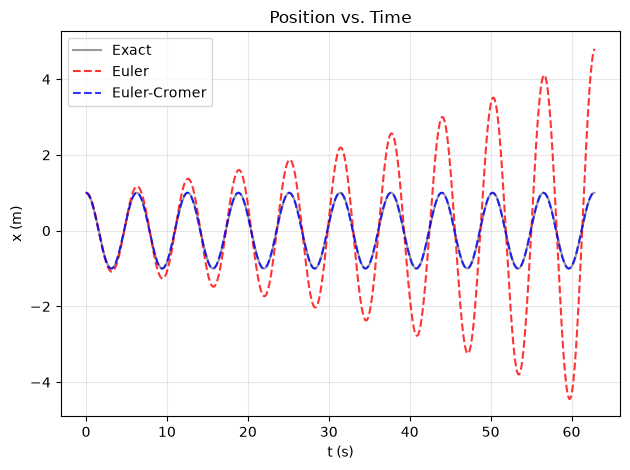

In [6]:
# Part 3
# Plotting x(t)

plt.plot(t_exact, exact_x(t_exact), color = 'black', alpha=0.4, label='Exact')
plt.plot(te, xe, alpha=0.8, label='Euler',linestyle='--', color = 'red')
plt.ylabel('x (m)')
plt.xlabel('t (s)')
plt.title('Position vs. Time')
plt.grid(True, alpha=0.3)
plt.plot(tc, xc, alpha=0.8, label='Euler-Cromer',linestyle='--', color = 'blue')
plt.legend()
plt.tight_layout()
plt.show()

This graph shows the Euler and Euler-Cromer's position as a function of time.

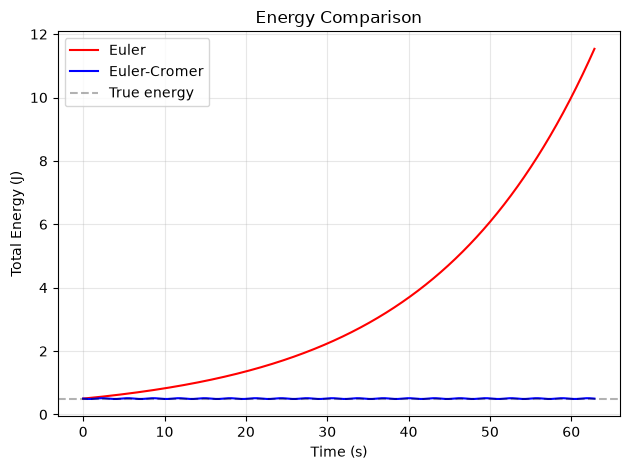

In [7]:
# Part 4
# Plot total energy vs time
plt.plot(te, ee, 'r-', label='Euler')
plt.plot(tc, ec, 'b-', label='Euler-Cromer')
plt.axhline(y=ee[0], color='k', linestyle='--', alpha=0.3, label='True energy')
plt.xlabel('Time (s)')
plt.ylabel('Total Energy (J)')
plt.title('Energy Comparison')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

This graph shows the Euler and Euler-Cromer's total energy as a function of time.

Part 5

What happens to the Euler solution's amplitude over 10 periods? What happens to its energy? Does Euler-Cromer show the same problem?

The Amplitude of the Euler function increases every amplitude, and its energy increases without bound. The Euler-Cromer function's amplitude does not increase and its energy oscillates around the true energy.

Part B — Phase Space & Damped Oscillations (35 points)

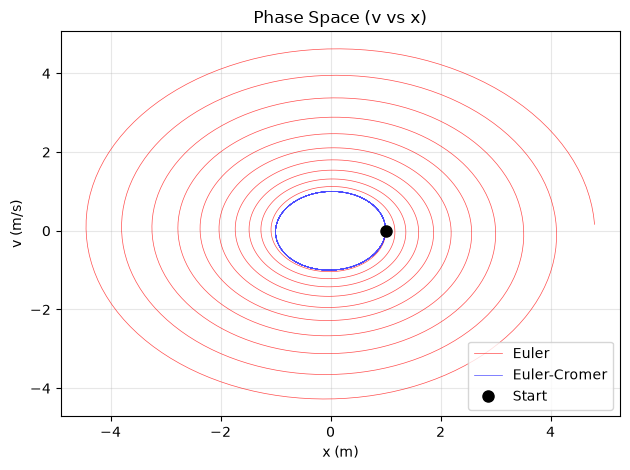

In [8]:
# B.1 Part 1
# Making a phase-space plot
# Euler phase portrait
plt.plot(xe, ve, 'r-', alpha=0.7, linewidth=0.5,label='Euler')

# Euler-Cromer phase portrait
plt.plot(xc, vc, 'b-', alpha=0.7, linewidth=0.5,label='Euler-Cromer')

plt.plot(xc[0], vc[0], 'ko', markersize=8, label='Start')
plt.xlabel('x (m)'); plt.ylabel('v (m/s)')
plt.title('Phase Space (v vs x)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

This graph shows the velocity and position relation of the Euler and Euler-Cromer Functions.

B.1 Part 2

What does the Euler curve do? What does the Euler-Cromer curve do? Connect the shape to what you saw in the energy plot.

The Euler curve continuously spirles outward, and the Euler-Cromer curve makes a circle in the center. This happens because the energy in the Euler function continues to increase causing the velocity and x postion to increase, while the Euler-Cromer function's energy does not increase and neither does its velocity or position.

In [9]:
# B.2 Part 1
# Adding Damping to the Function
def simulate_damped_sho(b, dt=0.02, t_max=30.0):
    """Simulate damped SHO with Euler-Cromer.
    beta = b/(2m) is the damping parameter.
    """
    beta = b/(2*m)
    x, v = x0, v0
    b_damp = 2 * m * beta  # recover b from beta
    ts, xs, vs, e = [0], [x], [v], [.5*k*(x**2)+.5*m*(v**2)]
    t = 0.0

    while t < t_max:
        # Force: spring + linear damping
        a = -(k / m) * x - (b_damp / m) * v

        # Euler-Cromer
        v = v + a * dt
        x = x + v * dt

        ee = .5*k*(x**2)+.5*m*(v**2)

        t += dt
        ts.append(t); xs.append(x); vs.append(v); e.append(ee)

    return np.array(ts), np.array(xs), np.array(vs), np.array(e)

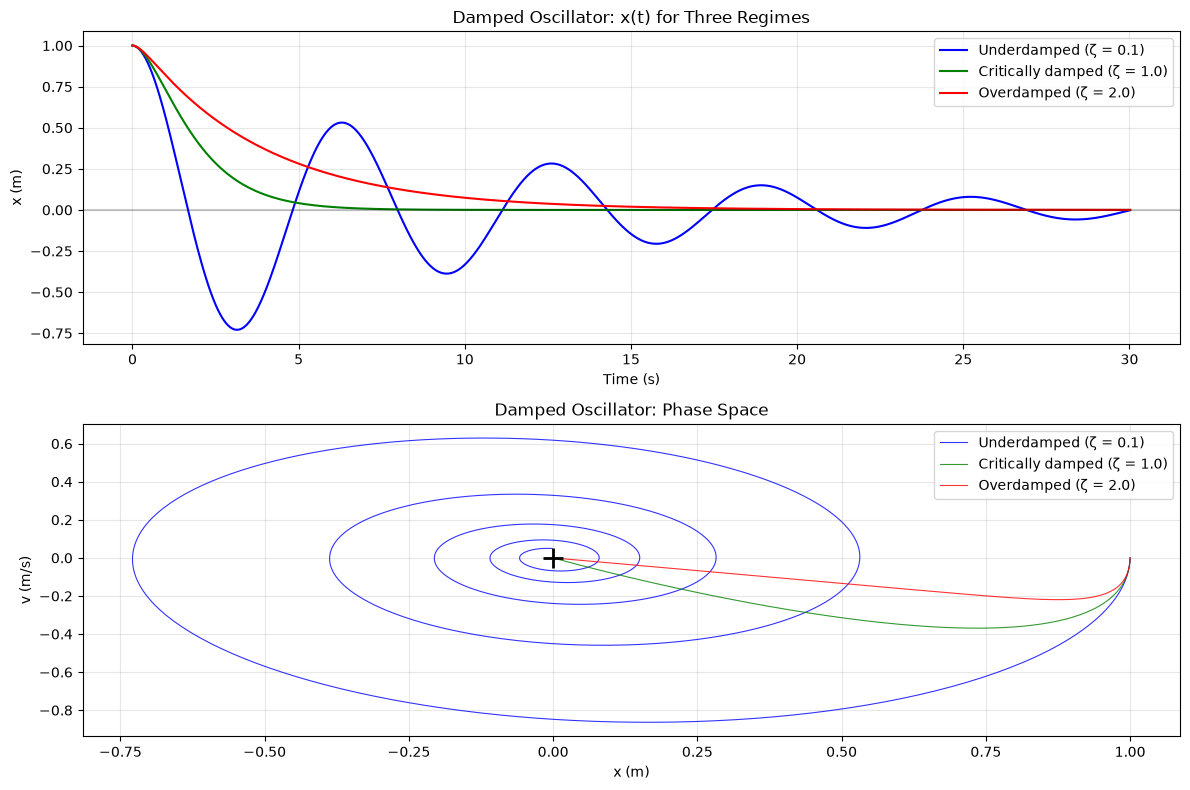

In [10]:
# B.2 Part 2 and 3
# Calling and plotting the functions

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

regimes = [
    (0.2,  'Underdamped (ζ = 0.1)',   'b'),
    (2.0, 'Critically damped (ζ = 1.0)', 'g'),
    (4.0,  'Overdamped (ζ = 2.0)',     'r'),
]

for beta, label, color in regimes:
    t, x, v, e = simulate_damped_sho(beta)
    axes[0].plot(t, x, color=color, label=label, linewidth=1.5)
    axes[1].plot(x, v, color=color, label=label, linewidth=0.8, alpha=0.8)

# x(t) plot
axes[0].set_xlabel('Time (s)'); axes[0].set_ylabel('x (m)')
axes[0].set_title('Damped Oscillator: x(t) for Three Regimes')
axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=0, color='k', alpha=0.2)

# Phase portrait
axes[1].set_xlabel('x (m)'); axes[1].set_ylabel('v (m/s)')
axes[1].set_title('Damped Oscillator: Phase Space')
axes[1].legend(); axes[1].grid(True, alpha=0.3)
axes[1].plot(0, 0, 'k+', markersize=15, markeredgewidth=2)  # equilibrium point

plt.tight_layout()
plt.show()

The top graph shows the position as a function of time for a underdamped, overdamped, and critically damped oscillator.

The bottom graph shows the phase space for a underdamped, overdamped, and critically damped oscillator.

B.2 Part 4

How does each regime spiral toward the origin differently?

The underdamped spirals in slowly, the overdamped makes a slight curve and take the most direct path there, and the overdamped does the same as the overdamped but with a larger curve making its path longer.

💡 Try it: For the underdamped case, overlay the theoretical decay envelope Ae−γt (where γ = b/2m) on your x(t) plot. Does your simulation's amplitude follow it?

Yes the simulation's amolitude follows the theoretical decay envelope.

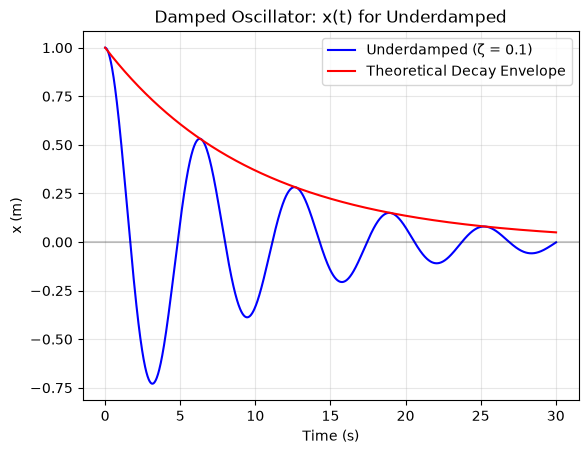

In [11]:
regimes = [
    (0.2,  'Underdamped (ζ = 0.1)',   'b'),
]

for beta, label, color in regimes:
    t, x, v, e = simulate_damped_sho(beta)
    plt.plot(t, x, color=color, label=label, linewidth=1.5)
    plt.plot(t, 1*math.e**((-1)*(.2/(2*m))*(t)), color = 'red', label='Theoretical Decay Envelope')

# x(t) plot
plt.xlabel('Time (s)'); plt.ylabel('x (m)')
plt.title('Damped Oscillator: x(t) for Underdamped')
plt.legend(); plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='k', alpha=0.2)

This graph shows a underdamped oscillator overlayed with its theoretical decay envelope.

Part C — Driven Oscillations & Resonance (40 points)

In [12]:
# Part 1
# Updating the function and giving constants

def simulate_driven_sho(omega_d, F0, b, dt=0.02, t_max=75.0):
    """Simulate driven, damped SHO with Euler-Cromer."""
    beta = b/(2*m)
    x, v = x0, v0
    b_damp = 2 * m * beta  # recover b from beta
    ts, xs, vs, e = [0], [x], [v], [.5*k*(x**2)+.5*m*(v**2)]
    t = 0.0

    while t < t_max:
        # Force: spring + linear damping + driving
        a = -(k / m) * x - (b_damp / m) * v + (F0/m)*np.cos(omega_d * t)

        # Euler-Cromer
        v = v + a * dt
        x = x + v * dt

        ee = .5*k*(x**2)+.5*m*(v**2)

        t += dt
        ts.append(t); xs.append(x); vs.append(v); e.append(ee)

    return np.array(ts), np.array(xs), np.array(vs), np.array(e)

b = 0.2      # light damping
F0 = 1.0     # driving amplitude
m = 1 
k = 1

omega_values = np.linspace(0.2, 2.0, 80)
amplitudes = []

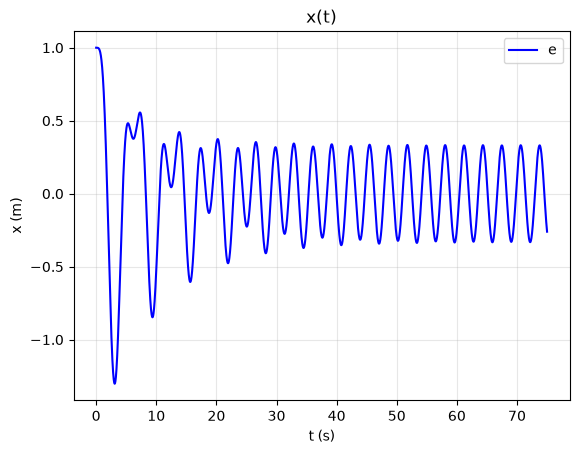

In [13]:
# Part 2
# Ploting x(t)

for omega_d in omega_values:
    t, x, v, e = simulate_driven_sho(omega_d, F0, b)
    # Steady-state amplitude: max of x in the last 20% of the simulation
    n_start = int(0.8 * len(x))
    amp = np.max(np.abs(x[n_start:]))
    amplitudes.append(amp)

plt.plot(t, x, color='blue', label='e', linewidth=1.5)
plt.xlabel('t (s)'); plt.ylabel('x (m)')
plt.title('x(t)')
plt.legend(); plt.grid(True, alpha=0.3)
plt.show()


The transient ends and steady state begins at the 35 second mark.

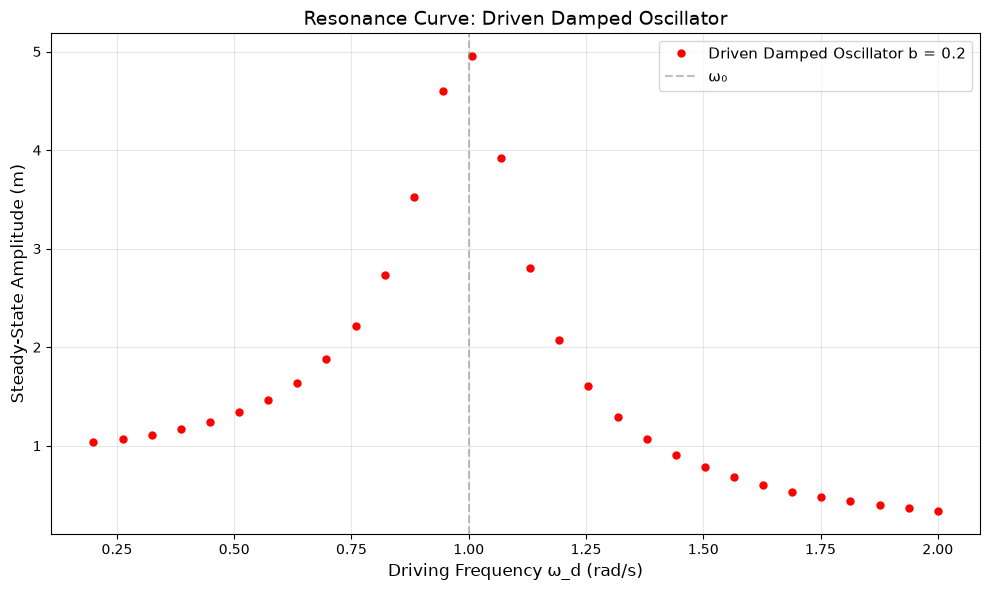

In [14]:
# Part 3
# Plotting a resonance curve

b = 0.2   # light damping
F0 = 1.0     # driving amplitude

omega_values = np.linspace(0.2, 2.0, 30)
amplitudes = []

for omega_d in omega_values:
    t, x, v, e = simulate_driven_sho(omega_d, F0, b)
    # Steady-state amplitude: max of x in the last 30% of the simulation
    n_start = int(0.7 * len(x))
    amp = np.max(np.abs(x[n_start:]))
    amplitudes.append(amp)

plt.figure(figsize=(10, 6))
plt.plot(omega_values, amplitudes, 'ro', markersize=5, label='Driven Damped Oscillator b = 0.2')
plt.axvline(x=omega0, color='gray', linestyle='--', alpha=0.5, label='ω₀')
plt.xlabel('Driving Frequency ω_d (rad/s)', fontsize=12)
plt.ylabel('Steady-State Amplitude (m)', fontsize=12)
plt.title('Resonance Curve: Driven Damped Oscillator', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Part 4

At what ωd does the amplitude peak? How does it compare to ω₀ = 1?

The peak amplitude appears to be around 5 m, which is at a ωd of 1 and that is equal to ω₀.


Part 5

Why does the amplitude peak near ω₀? What would happen to the peak height if you reduced the damping?

The amplitude peaks near ω₀ due to resonance. The peak height would grow larger as the damping decreases.

💡 Try it: Overlay two or three resonance curves for different damping values (e.g., b = 0.1, 0.2, 0.5). Watch the peak grow taller and sharper as damping decreases — that sharpness is the "quality factor" Q of the oscillator.

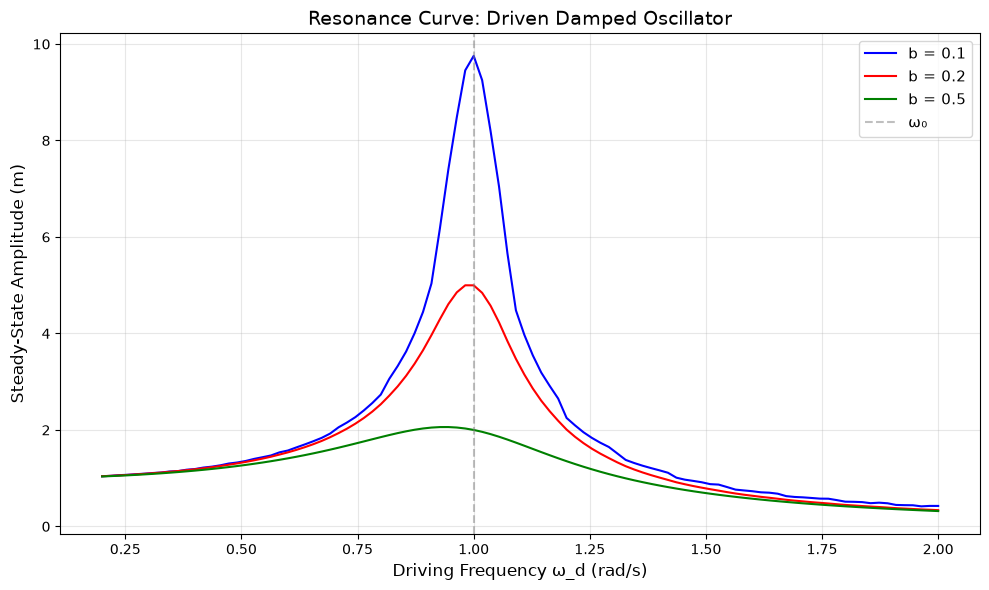

In [15]:
b_1 = 0.1
b_2 = 0.2
b_3 = 0.5
F0 = 1.0

omega_values = np.linspace(0.2, 2.0, 100)
amplitudes_1 = []
amplitudes_2 = []
amplitudes_3 = []

for omega_d in omega_values:
    t_1, x_1, v, e = simulate_driven_sho(omega_d, F0, b_1)
    t_2, x_2, v, e = simulate_driven_sho(omega_d, F0, b_2)
    t_3, x_3, v, e = simulate_driven_sho(omega_d, F0, b_3)
    # Steady-state amplitude: max of x in the last 30% of the simulation
    n_start_1 = int(0.7 * len(x_1))
    amp_1 = np.max(np.abs(x_1[n_start:]))
    amplitudes_1.append(amp_1)
    n_start_2 = int(0.7 * len(x_2))
    amp_2 = np.max(np.abs(x_2[n_start:]))
    amplitudes_2.append(amp_2)
    n_start_3 = int(0.7 * len(x_3))
    amp_3 = np.max(np.abs(x_3[n_start:]))
    amplitudes_3.append(amp_3)

plt.figure(figsize=(10, 6))
plt.plot(omega_values, amplitudes_1, color='blue', markersize=5, label='b = 0.1')
plt.plot(omega_values, amplitudes_2, color='red', markersize=5, label='b = 0.2')
plt.plot(omega_values, amplitudes_3, color ='green', markersize=5, label='b = 0.5')
plt.axvline(x=omega0, color='gray', linestyle='--', alpha=0.5, label='ω₀')
plt.xlabel('Driving Frequency ω_d (rad/s)', fontsize=12)
plt.ylabel('Steady-State Amplitude (m)', fontsize=12)
plt.title('Resonance Curve: Driven Damped Oscillator', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()